# IMDb Top 1000 Veri Seti ile Yapay Zeka Modelleri

Bu notebook'ta IMDb Top 1000 veri seti kullanılarak **film puanının yüksek olup olmadığı** tahmin edilmektedir.

Kullanılan modeller:

- Logistic Regression
- Decision Tree Classifier
- Support Vector Machine (SVM)
- Confusion Matrix ve başarı metrikleri

**Hedef değişken:** IMDb puanı `8.0 ve üzeri` ise film **yüksek puanlı**, değilse **normal puanlı** kabul edilmiştir.


In [23]:
# Gerekli kütüphaneler
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Kütüphaneler başarıyla yüklendi.")

Kütüphaneler başarıyla yüklendi.


## 1. Veri Setini Okuma

In [24]:

df = pd.read_csv("imdb_top_1000.csv")


df.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [25]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   str    
 1   Series_Title   1000 non-null   str    
 2   Released_Year  1000 non-null   str    
 3   Certificate    899 non-null    str    
 4   Runtime        1000 non-null   str    
 5   Genre          1000 non-null   str    
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   str    
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   str    
 10  Star1          1000 non-null   str    
 11  Star2          1000 non-null   str    
 12  Star3          1000 non-null   str    
 13  Star4          1000 non-null   str    
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    str    
dtypes: float64(2), int64(1), str(13)
memory usage: 125.1 KB


In [26]:

print("Satır sayısı:", df.shape[0])
print("Sütun sayısı:", df.shape[1])

Satır sayısı: 1000
Sütun sayısı: 16


## 2. Veri Temizleme

Bazı sütunlar metin gibi göründüğü için sayısal hâle getirilecektir:

- `Runtime`: "142 min" → 142
- `Gross`: "28,341,469" → 28341469
- `Released_Year`: sayısal yıla dönüştürme


In [27]:

df["Runtime"] = df["Runtime"].astype(str).str.replace(" min", "", regex=False)
df["Runtime"] = pd.to_numeric(df["Runtime"], errors="coerce")


df["Gross"] = df["Gross"].astype(str).str.replace(",", "", regex=False)
df["Gross"] = pd.to_numeric(df["Gross"], errors="coerce")

df["Released_Year"] = pd.to_numeric(df["Released_Year"], errors="coerce")


df.isnull().sum()

Poster_Link        0
Series_Title       0
Released_Year      1
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64

## 3. Hedef Değişken Oluşturma

Bu ödevde sınıflandırma yapılacağı için IMDb puanını iki sınıfa ayırıyoruz:

- `1` → IMDb puanı 8.0 ve üzeri olan filmler
- `0` → IMDb puanı 8.0'dan düşük olan filmler


In [28]:

df["High_Rated"] = np.where(df["IMDB_Rating"] >= 8.0, 1, 0)


df["High_Rated"].value_counts()

High_Rated
0    537
1    463
Name: count, dtype: int64

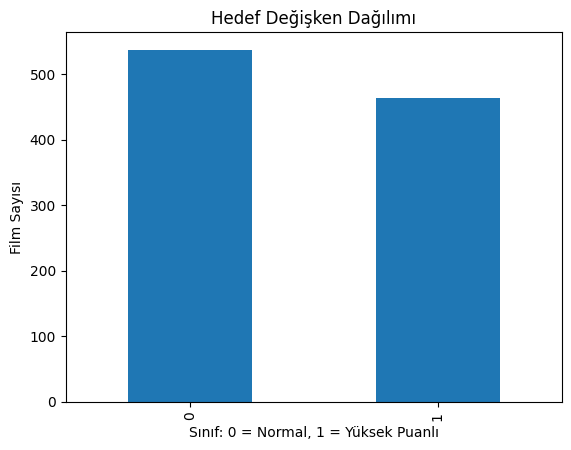

In [29]:

df["High_Rated"].value_counts().sort_index().plot(kind="bar")
plt.title("Hedef Değişken Dağılımı")
plt.xlabel("Sınıf: 0 = Normal, 1 = Yüksek Puanlı")
plt.ylabel("Film Sayısı")
plt.show()

## 4. Özellikleri Belirleme

Modeli eğitirken film adı, afiş linki ve açıklama gibi doğrudan model için uygun olmayan metin sütunları çıkarılmıştır.


In [30]:

features = [
    "Released_Year",
    "Runtime",
    "Meta_score",
    "No_of_Votes",
    "Gross",
    "Certificate",
    "Genre"
]

X = df[features]
y = df["High_Rated"]

X.head()

,Released_Year,Runtime,Meta_score,No_of_Votes,Gross,Certificate,Genre
0,1994.0,142,80.0,2343110,28341469.0,A,Drama
1,1972.0,175,100.0,1620367,134966411.0,A,"Crime, Drama"
2,2008.0,152,84.0,2303232,534858444.0,UA,"Action, Crime, Drama"
3,1974.0,202,90.0,1129952,57300000.0,A,"Crime, Drama"
4,1957.0,96,96.0,689845,4360000.0,U,"Crime, Drama"


## 5. Eğitim ve Test Verisine Ayırma

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Eğitim veri sayısı:", X_train.shape[0])
print("Test veri sayısı:", X_test.shape[0])

Eğitim veri sayısı: 800
Test veri sayısı: 200


## 6. Ön İşleme Pipeline'ı

Sayısal veriler için:

- Eksik değerler medyan ile doldurulur.
- StandardScaler ile ölçeklendirme yapılır.

Kategorik veriler için:

- Eksik değerler en sık görülen değerle doldurulur.
- OneHotEncoder ile sayısal forma çevrilir.


In [32]:
numeric_features = ["Released_Year", "Runtime", "Meta_score", "No_of_Votes", "Gross"]
categorical_features = ["Certificate", "Genre"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

## 7. Model Eğitme Fonksiyonu

Aşağıdaki fonksiyon modeli eğitir, tahmin yapar, doğruluk oranını gösterir ve confusion matrix çizer.


In [33]:
def train_and_evaluate_model(model, model_name):
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print("=" * 60)
    print(model_name)
    print("Accuracy:", round(accuracy, 4))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Normal", "Yüksek Puanlı"]
    )

    disp.plot()
    plt.title(model_name + " - Confusion Matrix")
    plt.show()

    return pipeline, accuracy

## 8. Logistic Regression Modeli

Logistic Regression
Accuracy: 0.705

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.75      0.73       107
           1       0.69      0.66      0.67        93

    accuracy                           0.70       200
   macro avg       0.70      0.70      0.70       200
weighted avg       0.70      0.70      0.70       200



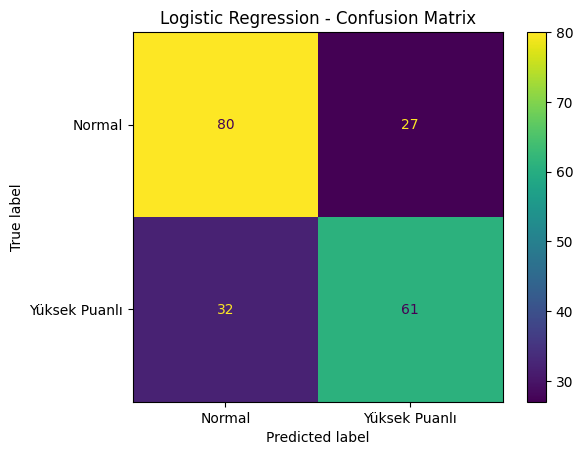

In [34]:
logistic_model, logistic_accuracy = train_and_evaluate_model(
    LogisticRegression(max_iter=1000),
    "Logistic Regression"
)

## 9. Decision Tree / Karar Ağacı Modeli

Decision Tree Classifier
Accuracy: 0.695

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.79      0.73       107
           1       0.71      0.59      0.64        93

    accuracy                           0.69       200
   macro avg       0.70      0.69      0.69       200
weighted avg       0.70      0.69      0.69       200



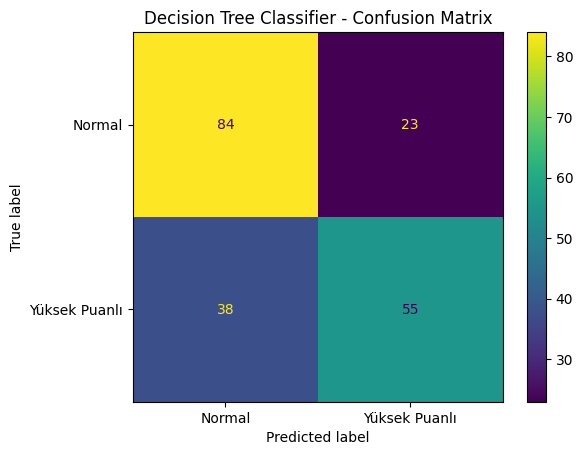

In [35]:
decision_tree_model, decision_tree_accuracy = train_and_evaluate_model(
    DecisionTreeClassifier(random_state=42, max_depth=5),
    "Decision Tree Classifier"
)

## 10. Support Vector Machine / Destek Vektör Makineleri

Support Vector Machine
Accuracy: 0.725

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.77      0.75       107
           1       0.72      0.68      0.70        93

    accuracy                           0.72       200
   macro avg       0.72      0.72      0.72       200
weighted avg       0.72      0.72      0.72       200



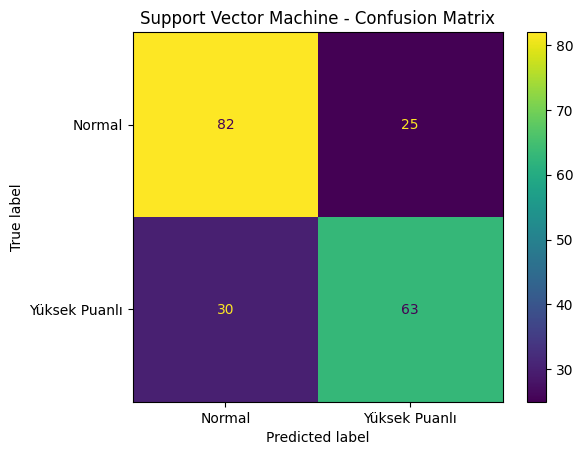

In [36]:
svm_model, svm_accuracy = train_and_evaluate_model(
    SVC(kernel="rbf", C=1.0, gamma="scale"),
    "Support Vector Machine"
)

## 11. Modelleri Karşılaştırma

In [37]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "SVM"],
    "Accuracy": [logistic_accuracy, decision_tree_accuracy, svm_accuracy]
})

results

,Model,Accuracy
0,Logistic Regression,0.705
1,Decision Tree,0.695
2,SVM,0.725


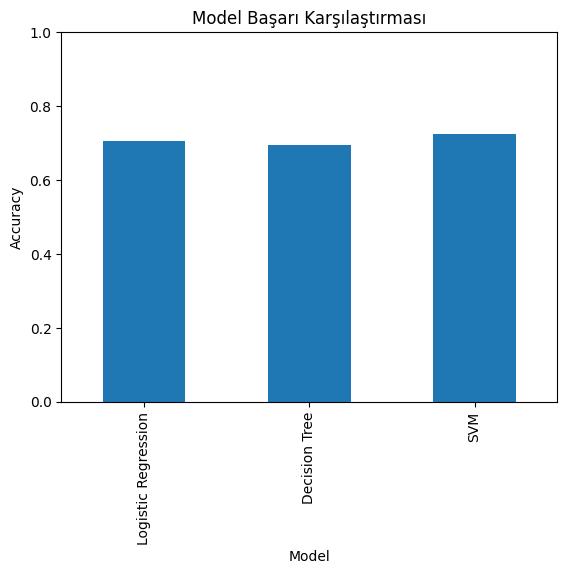

In [38]:
results.plot(x="Model", y="Accuracy", kind="bar", legend=False)
plt.title("Model Başarı Karşılaştırması")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

## 12. Sonuç Yorumu

Bu çalışmada IMDb Top 1000 veri seti kullanılarak filmlerin IMDb puanının yüksek olup olmadığı tahmin edilmiştir.

Üç farklı sınıflandırma algoritması kullanılmıştır:

1. Logistic Regression
2. Decision Tree Classifier
3. Support Vector Machine

Her model için accuracy değeri, classification report ve confusion matrix oluşturulmuştur. Confusion matrix sayesinde modelin hangi sınıfları doğru veya yanlış tahmin ettiği görülebilir.

Bu notebook, yapay zeka / makine öğrenmesi ödevinde sınıflandırma modellerini karşılaştırmak için kullanılabilir.
